# Alzheimer's Disease Diagnosis Analysis
## 目標：分析 Diagnosis 與各屬性的相關性，並建立高 Macro F1 的預測模型

## Cell 1｜套件安裝與載入

In [35]:
# ── 安裝所需套件 ──
import subprocess, sys
pkgs = ['xgboost', 'lightgbm', 'imbalanced-learn', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'])

# ── 載入套件 ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')
print('✅ 套件載入完成')

✅ 套件載入完成


## Cell 2｜資料載入與基本探索

In [36]:
df = pd.read_csv('data/tabular/alzheimers_disease_data.csv')
print('資料形狀:', df.shape)
print('\nDiagnosis 分布:')
print(df['Diagnosis'].value_counts())
print('\nDiagnosis 比例:')
print(df['Diagnosis'].value_counts(normalize=True).round(4))
df.head(3)

資料形狀: (2149, 35)

Diagnosis 分布:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis 比例:
Diagnosis
0    0.6463
1    0.3537
Name: proportion, dtype: float64


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


In [37]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Cell 3｜資料前處理

In [38]:
# 移除不需要的欄位（PatientID 為識別碼，DoctorInCharge 為機密資料）
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])
df_clean['Diagnosis'] = df_clean['Diagnosis'].astype(int)
print('處理後資料形狀:', df_clean.shape)
print('特徵欄位數量:', df_clean.shape[1] - 1)

處理後資料形狀: (2149, 33)
特徵欄位數量: 32


## Cell 4｜相關係數分析

In [39]:
corr_with_diagnosis = df_clean.corr()['Diagnosis'].drop('Diagnosis').sort_values(key=abs, ascending=False)
print('=== 各屬性與 Diagnosis 的 Pearson 相關係數（依絕對值排序）===')
print(corr_with_diagnosis.to_string())

=== 各屬性與 Diagnosis 的 Pearson 相關係數（依絕對值排序）===
FunctionalAssessment        -0.364898
ADL                         -0.332346
MemoryComplaints             0.306742
MMSE                        -0.237126
BehavioralProblems           0.224350
SleepQuality                -0.056548
EducationLevel              -0.043966
CholesterolHDL               0.042584
Hypertension                 0.035080
FamilyHistoryAlzheimers     -0.032900
CholesterolLDL              -0.031976
Diabetes                    -0.031508
CardiovascularDisease        0.031490
BMI                          0.026343
Disorientation              -0.024648
CholesterolTriglycerides     0.022672
HeadInjury                  -0.021411
Gender                      -0.020975
PersonalityChanges          -0.020627
Confusion                   -0.019186
SystolicBP                  -0.015615
Ethnicity                   -0.014782
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
AlcoholConsumption          -0.007618
Chole

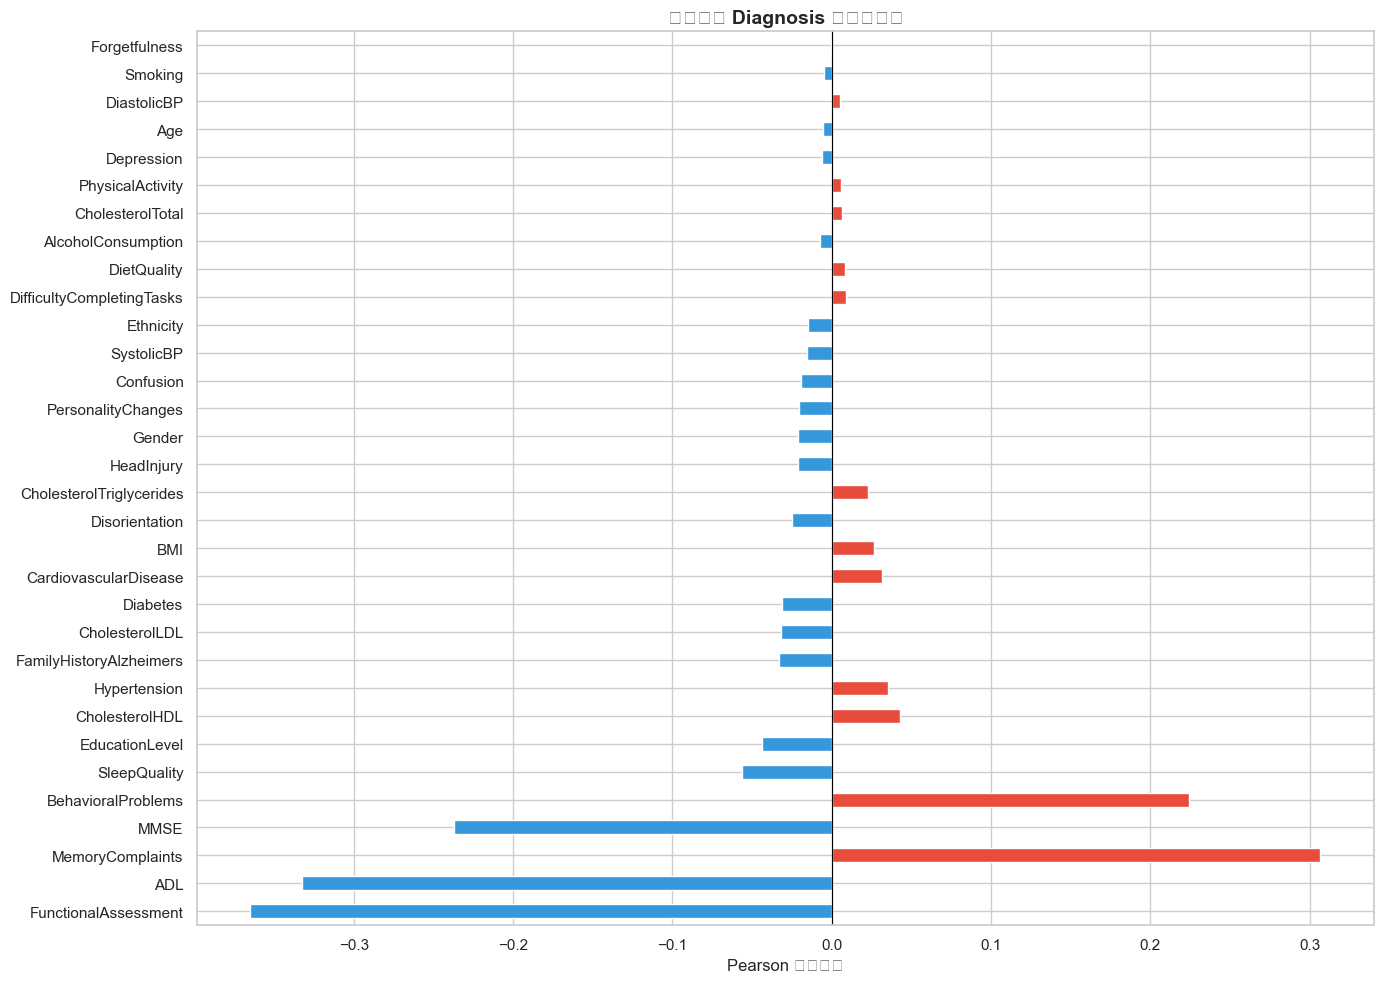

圖表已儲存 → correlation_with_diagnosis.png


In [40]:
# 橫條圖：各屬性與 Diagnosis 的相關係數
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_diagnosis.values]
corr_with_diagnosis.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Pearson 相關係數', fontsize=12)
ax.set_title('各屬性與 Diagnosis 的相關係數', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('correlation_with_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存 → correlation_with_diagnosis.png')

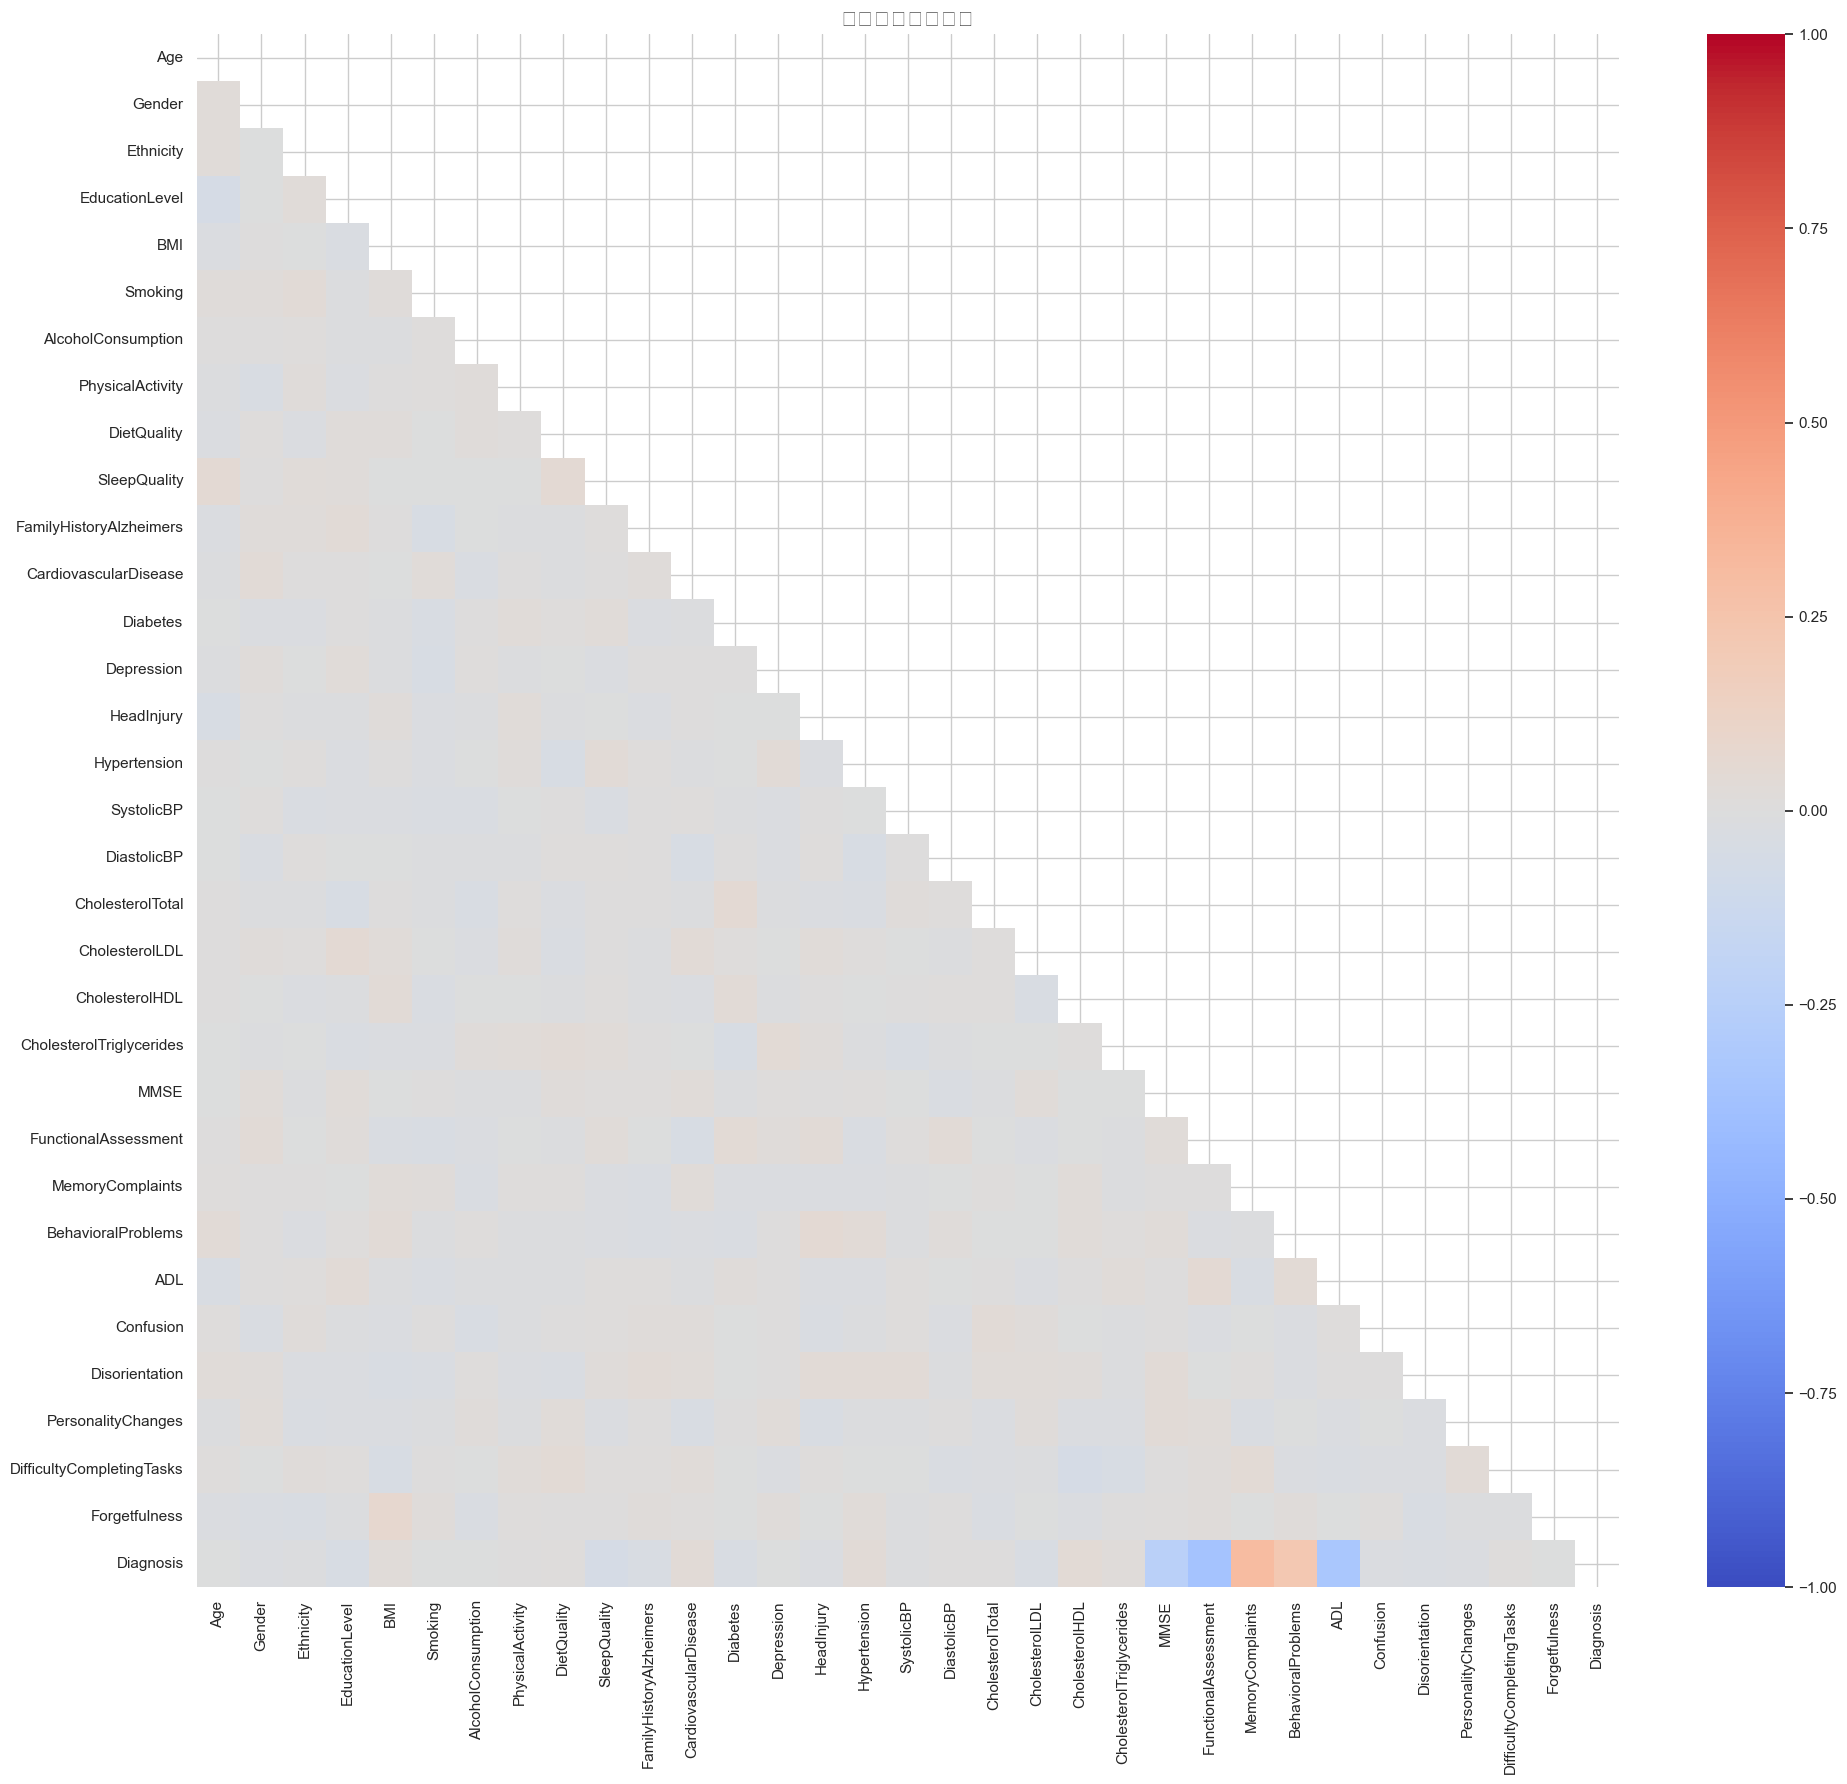

In [41]:
# 相關矩陣熱圖
fig, ax = plt.subplots(figsize=(20, 18))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('特徵相關矩陣熱圖', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5｜各屬性分布分析（Diagnosis 0 vs 1）

Top 6 相關特徵: ['FunctionalAssessment', 'ADL', 'MemoryComplaints', 'MMSE', 'BehavioralProblems', 'SleepQuality']


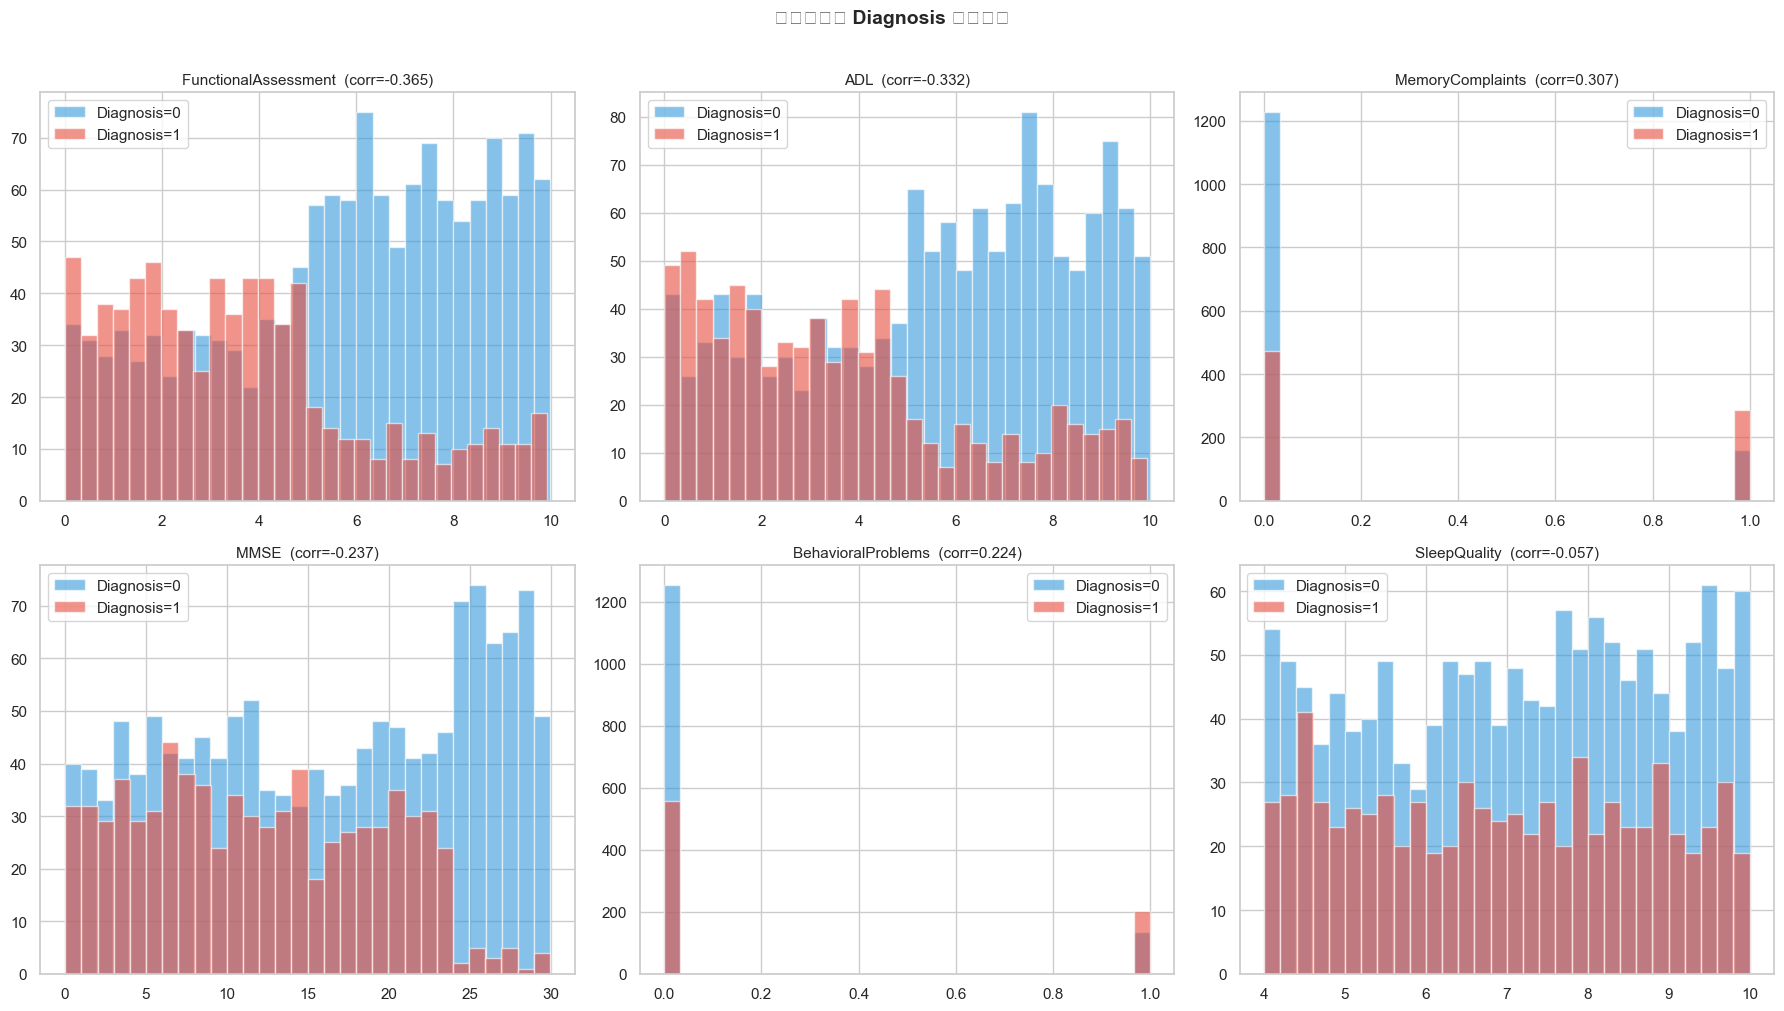

In [42]:
top_features = corr_with_diagnosis.head(6).index.tolist()
print('Top 6 相關特徵:', top_features)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    for label, color in zip([0, 1], ['#3498db', '#e74c3c']):
        axes[i].hist(df_clean[df_clean['Diagnosis'] == label][feat].dropna(),
                     alpha=0.6, bins=30, color=color,
                     label=f'Diagnosis={label}')
    axes[i].set_title(f'{feat}  (corr={corr_with_diagnosis[feat]:.3f})', fontsize=11)
    axes[i].legend()
plt.suptitle('重要特徵按 Diagnosis 分組分布', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6｜特徵準備、SMOTE 過採樣、模型訓練（All-in-One）

In [43]:
# ── 特徵 / 標籤分割 ──
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']
print('特徵維度:', X.shape)
print('標籤分布:', y.value_counts().to_dict())

# ── 訓練 / 測試分割 ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'訓練集: {X_train.shape[0]} 筆，測試集: {X_test.shape[0]} 筆')

# ── 標準化 ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE 過採樣（解決類別不平衡）──
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
print('SMOTE 後訓練集:', pd.Series(y_train_res).value_counts().to_dict())

# ── 定義模型 ──
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'SVM': SVC(
        kernel='rbf', C=10, gamma='scale', class_weight='balanced',
        probability=True, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=42, verbosity=-1),
}

# ── 訓練並評估 ──
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('\n{:<30s} | {:>14s} | {:>12s}'.format('Model', 'Test MacroF1', 'CV MacroF1'))
print('-' * 62)
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred    = model.predict(X_test_sc)
    macro_f1  = f1_score(y_test, y_pred, average='macro')
    cv_f1     = cross_val_score(model, X_train_res, y_train_res,
                                cv=cv, scoring='f1_macro', n_jobs=1).mean()
    results[name] = {'macro_f1': macro_f1, 'cv_f1': cv_f1,
                     'model': model, 'y_pred': y_pred}
    print(f'{name:<30s} | {macro_f1:>14.4f} | {cv_f1:>12.4f}')

特徵維度: (2149, 32)
標籤分布: {0: 1389, 1: 760}
訓練集: 1719 筆，測試集: 430 筆
SMOTE 後訓練集: {0: 1111, 1: 1111}

Model                          |   Test MacroF1 |   CV MacroF1
--------------------------------------------------------------
Logistic Regression            |         0.8077 |       0.8423
Random Forest                  |         0.9355 |       0.9577
Gradient Boosting              |         0.9335 |       0.9532
SVM                            |         0.7968 |       0.8721
XGBoost                        |         0.9463 |       0.9541
LightGBM                       |         0.9386 |       0.9577


## Cell 7｜模型比較視覺化

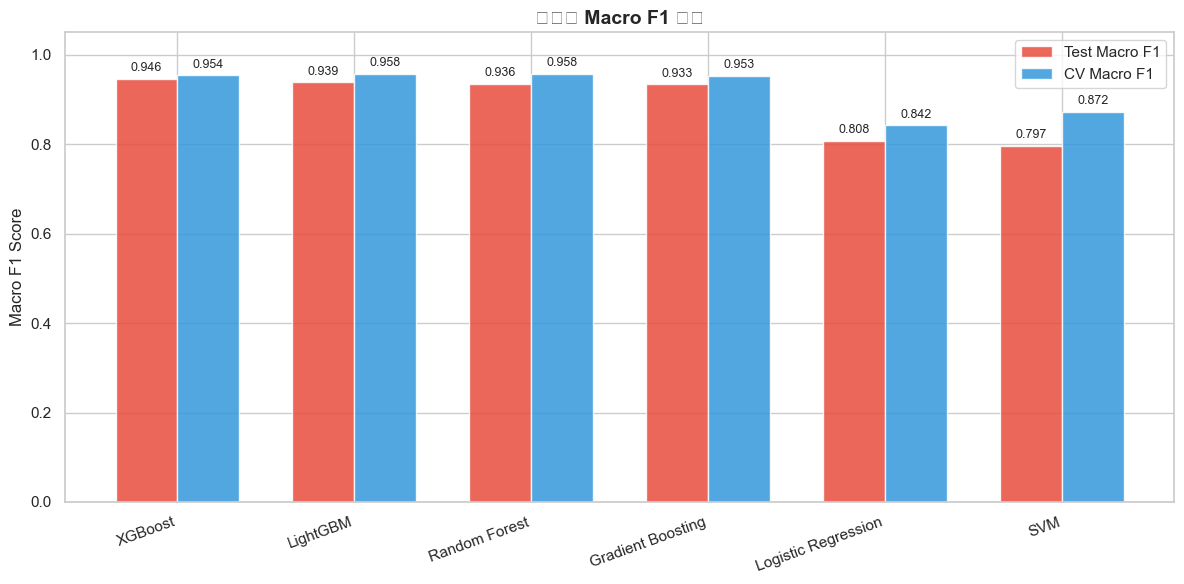

              Model  Test MacroF1  CV MacroF1
            XGBoost      0.946333    0.954073
           LightGBM      0.938571    0.957672
      Random Forest      0.935503    0.957671
  Gradient Boosting      0.933452    0.953175
Logistic Regression      0.807665    0.842281
                SVM      0.796844    0.872073


In [44]:
result_df = pd.DataFrame({
    'Model':        list(results.keys()),
    'Test MacroF1': [v['macro_f1'] for v in results.values()],
    'CV MacroF1':   [v['cv_f1']   for v in results.values()],
}).sort_values('Test MacroF1', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
x, w = np.arange(len(result_df)), 0.35
bars1 = ax.bar(x - w/2, result_df['Test MacroF1'], w, label='Test Macro F1', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, result_df['CV MacroF1'],   w, label='CV Macro F1',   color='#3498db', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(result_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Macro F1 Score')
ax.set_title('各模型 Macro F1 比較', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(result_df.to_string(index=False))

## Cell 8｜最佳模型詳細分析

In [45]:
best_name  = max(results, key=lambda k: results[k]['macro_f1'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']
print(f'✅ 最佳模型: {best_name}')
print(f'   Macro F1 Score: {results[best_name]["macro_f1"]:.4f}')
print('\n── 分類報告 ──')
print(classification_report(y_test, best_pred,
      target_names=["No Alzheimer's (0)", "Alzheimer's (1)"]))

✅ 最佳模型: XGBoost
   Macro F1 Score: 0.9463

── 分類報告 ──
                    precision    recall  f1-score   support

No Alzheimer's (0)       0.96      0.97      0.96       278
   Alzheimer's (1)       0.94      0.92      0.93       152

          accuracy                           0.95       430
         macro avg       0.95      0.94      0.95       430
      weighted avg       0.95      0.95      0.95       430



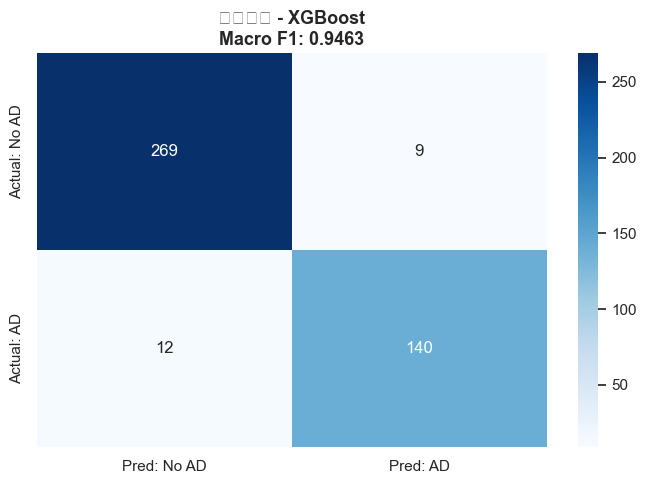

In [46]:
# 混淆矩陣
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No AD', 'Pred: AD'],
            yticklabels=['Actual: No AD', 'Actual: AD'])
ax.set_title(f'混淆矩陣 - {best_name}\nMacro F1: {results[best_name]["macro_f1"]:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

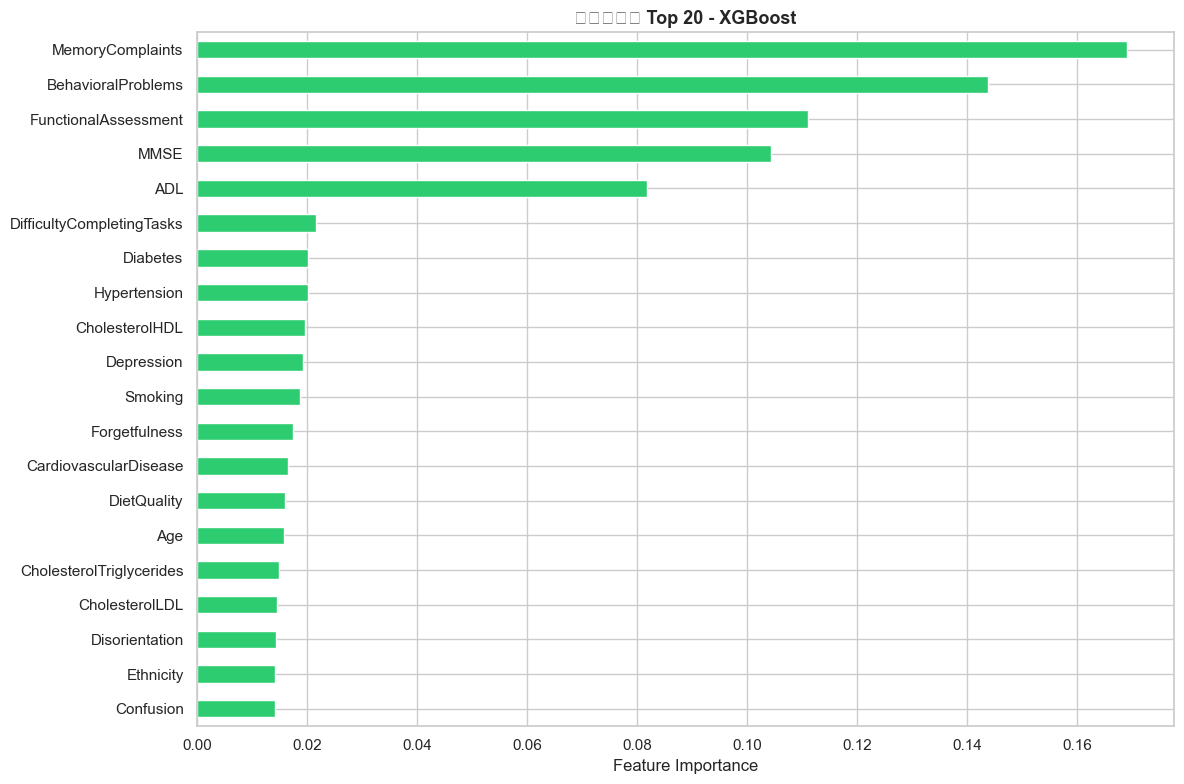

Top 15 特徵：
MemoryComplaints             0.169109
BehavioralProblems           0.143695
FunctionalAssessment         0.111007
MMSE                         0.104378
ADL                          0.081847
DifficultyCompletingTasks    0.021700
Diabetes                     0.020179
Hypertension                 0.020122
CholesterolHDL               0.019620
Depression                   0.019257
Smoking                      0.018704
Forgetfulness                0.017543
CardiovascularDisease        0.016560
DietQuality                  0.016016
Age                          0.015847


In [47]:
# 特徵重要性（tree-based 模型）
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
    feat_imp_sorted = feat_imp.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 8))
    feat_imp_sorted.head(20).plot(kind='barh', ax=ax, color='#2ecc71')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'特徵重要性 Top 20 - {best_name}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Top 15 特徵：')
    print(feat_imp_sorted.head(15).to_string())
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False)
    print('Top 15 係數（絕對值）：')
    print(coef.head(15).to_string())

## Cell 9｜Ensemble 投票模型（進一步提升 Macro F1）

In [ ]:
top3 = sorted(results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)[:3]
print('Top 3 模型:', [t[0] for t in top3])

# XGBoost 有時與 VotingClassifier 不相容，過濾掉
from sklearn.base import is_classifier
valid_top3 = [(name, results[name]['model']) for name, _ in top3 if is_classifier(results[name]['model'])]
print('Valid estimators for Voting:', [n for n,_ in valid_top3])

try:
    ensemble = VotingClassifier(estimators=valid_top3, voting='soft')
    ensemble.fit(X_train_res, y_train_res)
    y_pred_ens   = ensemble.predict(X_test_sc)
    ens_macro_f1 = f1_score(y_test, y_pred_ens, average='macro')
    print(f'\n✅ Ensemble Macro F1: {ens_macro_f1:.4f}')
    print(classification_report(y_test, y_pred_ens, target_names=['No AD (0)', 'AD (1)']))
except Exception as e:
    print(f'Ensemble 失敗: {e}')
    # Fallback: 直接用最佳單一模型
    best_name_fb  = max(results, key=lambda k: results[k]['macro_f1'])
    ens_macro_f1  = results[best_name_fb]['macro_f1']
    print(f'Fallback: 使用最佳模型 {best_name_fb}, Macro F1={ens_macro_f1:.4f}')


## Cell 10｜結果總結

In [49]:
print("="*65)
print("  最終結果總結")
print("="*65)
print(f"資料集: {df.shape[0]} 筆，特徵數: {X.shape[1]} 個")
print(f"Diagnosis 分布: 0={y.value_counts()[0]}, 1={y.value_counts()[1]}")

print("\n── 相關係數前 10 名 ──")
print(corr_with_diagnosis.head(10).to_string())

print("\n── 各模型 Macro F1 ──")
for name, res in sorted(results.items(), key=lambda x: x[1]["macro_f1"], reverse=True):
    print(f"  {name:<30s}: {res['macro_f1']:.4f}")

# Ensemble 結果（若有執行 Cell 9 才會有）
try:
    print(f"  {'Ensemble (Top3 Soft Voting)':<30s}: {ens_macro_f1:.4f}")
    all_scores = [(n, r["macro_f1"]) for n, r in results.items()] + [("Ensemble", ens_macro_f1)]
except NameError:
    print("  (Ensemble cell 未執行，跳過)")
    all_scores = [(n, r["macro_f1"]) for n, r in results.items()]

final_best = max(all_scores, key=lambda x: x[1])
print(f"\n🏆 最佳模型 : {final_best[0]}")
print(f"🏆 最高 Macro F1 : {final_best[1]:.4f}")

  最終結果總結
資料集: 2149 筆，特徵數: 32 個
Diagnosis 分布: 0=1389, 1=760

── 相關係數前 10 名 ──
FunctionalAssessment      -0.364898
ADL                       -0.332346
MemoryComplaints           0.306742
MMSE                      -0.237126
BehavioralProblems         0.224350
SleepQuality              -0.056548
EducationLevel            -0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers   -0.032900

── 各模型 Macro F1 ──
  XGBoost                       : 0.9463
  LightGBM                      : 0.9386
  Random Forest                 : 0.9355
  Gradient Boosting             : 0.9335
  Logistic Regression           : 0.8077
  SVM                           : 0.7968
  Ensemble (Top3 Soft Voting)   : 0.9412

🏆 最佳模型 : XGBoost
🏆 最高 Macro F1 : 0.9463
